# MODULE 2 — CSP Feature Extraction + LASSO Selection
**Requires:** `eeg_data_bundle.pkl` from Module 1

**Goal:** Extract 10-band OVR-CSP features, run LASSO selection, visualise class separability.

✅ **Pass criterion:** Selected features show class separation better than random (LDA accuracy > 35%)

In [1]:
import numpy as np
import scipy.signal as sig
import matplotlib.pyplot as plt
import pickle, warnings
warnings.filterwarnings('ignore')
from scipy.linalg import eigh
from sklearn.linear_model import LassoCV
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
from sklearn.manifold import TSNE

with open('eeg_data_bundle.pkl', 'rb') as f:
    d = pickle.load(f)

X_raw    = d['X_raw']
y_enc    = d['y_enc']
subjects = d['subjects']
sessions = d['sessions']
S0, S1   = d['S0'], d['S1']
BANDS    = d['BANDS']
FS       = d['FS']
CLASSES  = d['classes']
SEED     = 42

BAND_NAMES = [f'{lo}-{hi}' for lo,hi in BANDS]
print('Data bundle loaded.')
print(f'X: {X_raw.shape}  classes: {CLASSES}')

Data bundle loaded.
X: (5184, 22, 1000)  classes: ['feet' 'left_hand' 'right_hand' 'tongue']


## 2.1 CSP Implementation (OVR, paper Sec. 2.3)

In [2]:
def bandpass(X, lo, hi, fs=FS, order=5):
    nyq  = fs/2
    b, a = sig.butter(order, [lo/nyq, hi/nyq], btype='band')
    return sig.filtfilt(b, a, X, axis=-1).astype(np.float32)

def zscore(X_tr, X_other):
    mu  = X_tr.mean(axis=(0,2), keepdims=True)
    std = X_tr.std (axis=(0,2), keepdims=True) + 1e-8
    return (X_tr-mu)/std, (X_other-mu)/std

def csp_ovr_band(X_band, y, n_comp=4):
    """
    One-vs-Rest CSP for one frequency band (paper Sec. 2.3, Eq. 2-3).
    Returns:
      feats  : (n_trials, n_classes * n_comp)  log-variance features
      W_list : list of n_classes spatial filters, each (n_ch, n_comp)
    """
    classes = np.unique(y)
    feats, W_list = [], []

    for cls in classes:
        Xc = X_band[y == cls]    # this class
        Xo = X_band[y != cls]    # rest

        def norm_cov_mean(Xset):
            covs = [t @ t.T / (np.trace(t @ t.T) + 1e-8) for t in Xset]
            return np.mean(covs, axis=0)

        R1, R2 = norm_cov_mean(Xc), norm_cov_mean(Xo)
        # Generalised eigenvalue problem: R1 w = λ (R1+R2) w
        vals, vecs = eigh(R1, R1 + R2)
        # Take top n_comp eigenvectors (largest eigenvalues)
        W = vecs[:, np.argsort(vals)[::-1][:n_comp]]  # (n_ch, n_comp)
        W_list.append(W)

        # Log-variance features  (n_trials, n_comp)
        Z    = np.stack([W.T @ trial for trial in X_band])   # (N, n_comp, T)
        feat = np.log(np.var(Z, axis=2) + 1e-8)
        feats.append(feat)

    return np.hstack(feats), W_list   # (N, 4*n_comp), list-of-4


def extract_all_band_csp(X, y):
    """
    Apply OVR-CSP to all 10 filter bands.
    Returns feature matrix (N, 160) and list of spatial filters.
    """
    all_feats, all_filters = [], []
    for lo, hi in BANDS:
        Xb          = bandpass(X, lo, hi)
        feat, W_lst = csp_ovr_band(Xb, y)
        all_feats.append(feat)
        all_filters.append(W_lst)
    return np.hstack(all_feats), all_filters   # (N, 160)

print('CSP functions defined.')

CSP functions defined.


## 2.2 LASSO Feature Selection (paper Sec. 2.4, Eq. 5)

In [3]:
def lasso_select(features, y, min_k=10):
    """
    LASSO (L1-penalised regression) selects sparse subset of CSP features.
    Returns indices of selected features.
    """
    lasso = LassoCV(cv=5, max_iter=20000, random_state=SEED, n_jobs=-1)
    lasso.fit(features, y.astype(float))
    idx = np.where(np.abs(lasso.coef_) > 0)[0]
    if len(idx) < min_k:   # fallback: top-k by magnitude
        idx = np.argsort(np.abs(lasso.coef_))[::-1][:min_k]
    return np.sort(idx)

print('LASSO function defined.')

LASSO function defined.


## 2.3 Run on One LOSO Fold (Subject 1 as test)

In [4]:
TEST_SUBJ = '1'

m_tr = subjects != TEST_SUBJ
m_te = (subjects == TEST_SUBJ) & (sessions == S1)

X_tr_raw, y_tr = X_raw[m_tr], y_enc[m_tr]
X_te_raw, y_te = X_raw[m_te], y_enc[m_te]

# Z-score
X_tr, X_te = zscore(X_tr_raw, X_te_raw)

print(f'Train: {X_tr.shape}  Test: {X_te.shape}')
print('Extracting CSP features (10 bands × 4 classes × 4 components)...')

F_tr, W_all = extract_all_band_csp(X_tr, y_tr)
F_te, _     = extract_all_band_csp(X_te, y_te)

print(f'Feature matrix: {F_tr.shape}  (expected 160 dims)')

print('Running LASSO selection...')
sel_idx = lasso_select(F_tr, y_tr)
print(f'Selected: {len(sel_idx)}/{F_tr.shape[1]} features')

F_tr_sel = F_tr[:, sel_idx]
F_te_sel = F_te[:, sel_idx]

Train: (4608, 22, 1000)  Test: (288, 22, 1000)
Extracting CSP features (10 bands × 4 classes × 4 components)...
Feature matrix: (4608, 160)  (expected 160 dims)
Running LASSO selection...
Selected: 49/160 features


## 2.4 Visualise: Feature Importance (LASSO Coefficients)

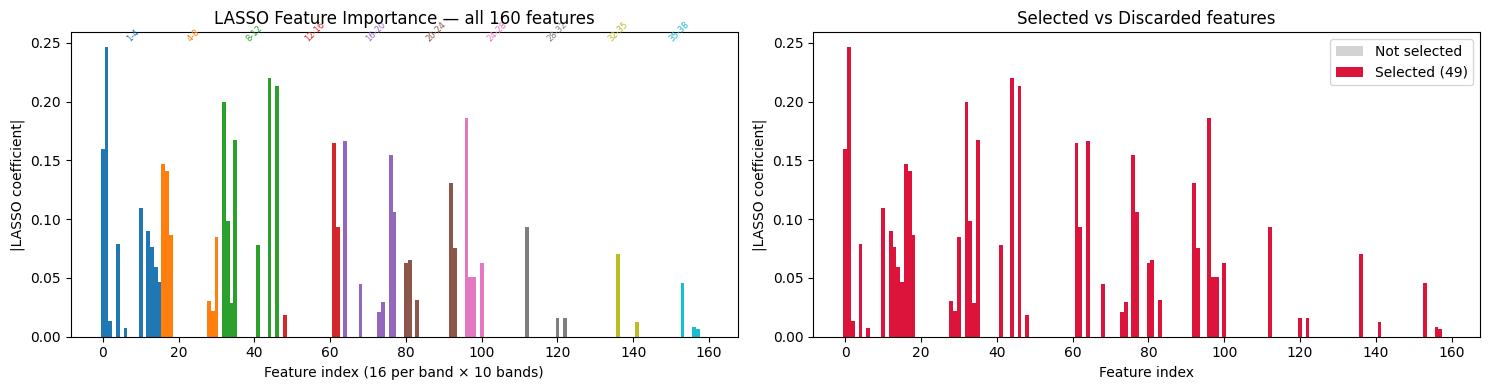

In [5]:
# Re-fit LASSO to get all coefficients for plotting
from sklearn.linear_model import LassoCV
lasso_viz = LassoCV(cv=5, max_iter=20000, random_state=SEED, n_jobs=-1)
lasso_viz.fit(F_tr, y_tr.astype(float))
coefs = np.abs(lasso_viz.coef_)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# All 160 coefficients, coloured by band
colors_band = plt.cm.tab10(np.repeat(np.arange(10), 16))
axes[0].bar(np.arange(160), coefs, color=colors_band, width=1.0)
axes[0].set_xlabel('Feature index (16 per band × 10 bands)')
axes[0].set_ylabel('|LASSO coefficient|')
axes[0].set_title('LASSO Feature Importance — all 160 features')
# Band labels
for i, name in enumerate(BAND_NAMES):
    axes[0].text(i*16+8, coefs.max()*1.02, name, ha='center',
                 fontsize=6, rotation=45, color=plt.cm.tab10(i/10))

# Selected feature indices highlighted
mask = np.zeros(160, dtype=bool)
mask[sel_idx] = True
axes[1].bar(np.arange(160)[~mask], coefs[~mask], color='lightgray', width=1.0, label='Not selected')
axes[1].bar(np.arange(160)[mask],  coefs[mask],  color='crimson',   width=1.0, label=f'Selected ({mask.sum()})')
axes[1].set_xlabel('Feature index')
axes[1].set_ylabel('|LASSO coefficient|')
axes[1].set_title('Selected vs Discarded features')
axes[1].legend()

plt.tight_layout()
plt.savefig('m2_lasso_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.5 Visualise: Class Separability (t-SNE)

Running t-SNE (may take ~30s)...


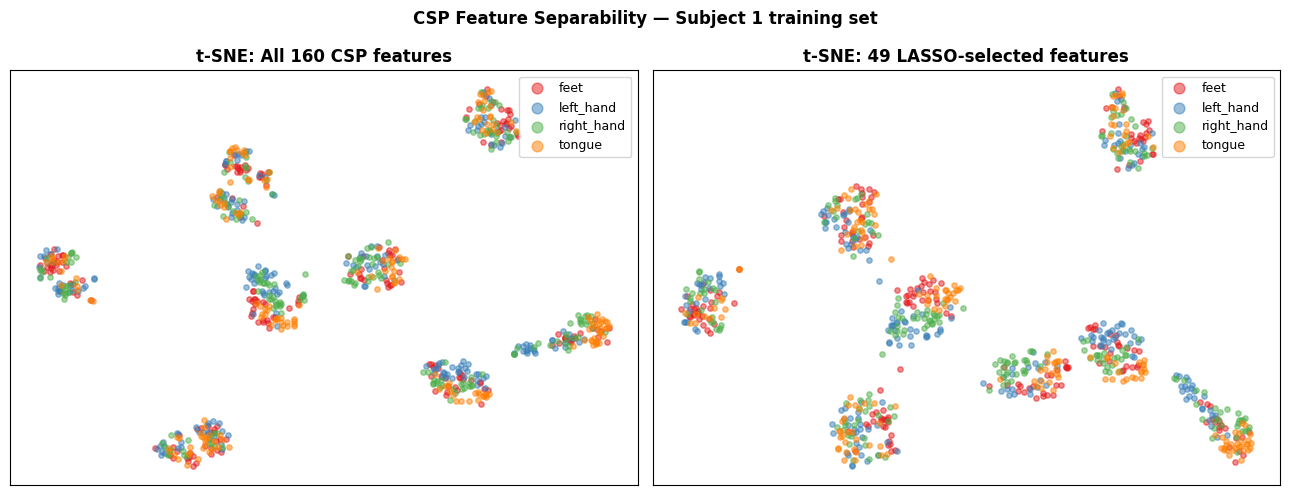

In [6]:
# t-SNE on training features — all 160 vs selected
print('Running t-SNE (may take ~30s)...')
tsne = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)

# Subsample for speed
n_viz  = min(800, len(F_tr))
idx_v  = np.random.choice(len(F_tr), n_viz, replace=False)

F2_all = tsne.fit_transform(F_tr[idx_v])
tsne2  = TSNE(n_components=2, perplexity=40, random_state=SEED, max_iter=1000)
F2_sel = tsne2.fit_transform(F_tr_sel[idx_v])

y_viz  = y_tr[idx_v]
colors_cls = ['#e41a1c','#377eb8','#4daf4a','#ff7f00']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for cls in range(4):
    m = y_viz == cls
    axes[0].scatter(F2_all[m,0], F2_all[m,1], c=colors_cls[cls],
                    alpha=0.5, s=15, label=d['classes'][cls])
    axes[1].scatter(F2_sel[m,0], F2_sel[m,1], c=colors_cls[cls],
                    alpha=0.5, s=15, label=d['classes'][cls])

axes[0].set_title('t-SNE: All 160 CSP features', fontweight='bold')
axes[1].set_title(f't-SNE: {len(sel_idx)} LASSO-selected features', fontweight='bold')
for ax in axes:
    ax.legend(markerscale=2, fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('CSP Feature Separability — Subject 1 training set', fontweight='bold')
plt.tight_layout()
plt.savefig('m2_tsne_features.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.6 Pass/Fail Check: LDA Accuracy on Selected Features

LDA 5-fold CV accuracy (all 160 features) : 47.9%
LDA 5-fold CV accuracy ( 49 LASSO feats): 47.5%
Chance = 25%


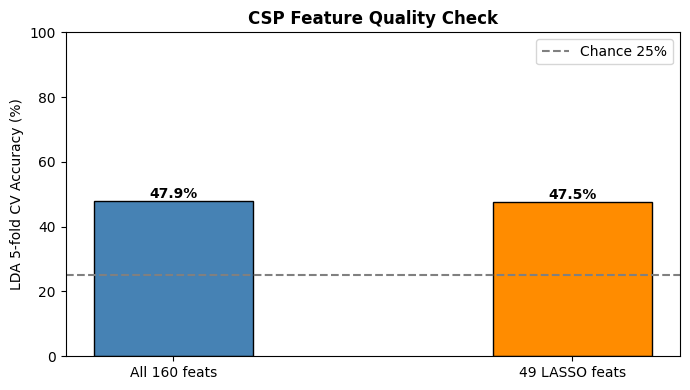


✅  MODULE 2 PASS — CSP+LASSO features carry class signal (47.9% > 35%)


In [7]:
# Quick LDA cross-val on training set — verifies features carry class signal
lda  = LDA()
cv_scores_all = cross_val_score(lda, F_tr,     y_tr, cv=5, scoring='accuracy')
cv_scores_sel = cross_val_score(lda, F_tr_sel, y_tr, cv=5, scoring='accuracy')

print(f'LDA 5-fold CV accuracy (all 160 features) : {cv_scores_all.mean()*100:.1f}%')
print(f'LDA 5-fold CV accuracy ({len(sel_idx):3d} LASSO feats): {cv_scores_sel.mean()*100:.1f}%')
print(f'Chance = 25%')

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(['All 160 feats', f'{len(sel_idx)} LASSO feats'],
       [cv_scores_all.mean()*100, cv_scores_sel.mean()*100],
       color=['steelblue','darkorange'], edgecolor='k', width=0.4)
ax.axhline(25, color='gray', ls='--', lw=1.5, label='Chance 25%')
ax.set_ylim(0, 100); ax.set_ylabel('LDA 5-fold CV Accuracy (%)')
ax.set_title('CSP Feature Quality Check', fontweight='bold')
ax.legend()
for i, v in enumerate([cv_scores_all.mean()*100, cv_scores_sel.mean()*100]):
    ax.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('m2_lda_accuracy.png', dpi=120, bbox_inches='tight')
plt.show()

# ── PASS / FAIL ───────────────────────────────────────────────────────────
best_acc = max(cv_scores_all.mean(), cv_scores_sel.mean()) * 100
assert best_acc > 35.0, f'FAIL: LDA accuracy {best_acc:.1f}% — features carry no signal'
print(f'\n✅  MODULE 2 PASS — CSP+LASSO features carry class signal ({best_acc:.1f}% > 35%)')

## 2.7 Save CSP/LASSO Functions for Next Modules

In [8]:
# Save the feature extraction functions via dill/pickle is tricky,
# so we save the verified results for subject-1 fold as a smoke test.
csp_bundle = dict(
    F_tr_sel = F_tr_sel,
    F_te_sel = F_te_sel,
    sel_idx  = sel_idx,
    y_tr     = y_tr,
    y_te     = y_te,
)
with open('eeg_csp_bundle.pkl','wb') as f:
    pickle.dump(csp_bundle, f)
print('Saved eeg_csp_bundle.pkl')
print(f'  sel_idx : {len(sel_idx)} features selected out of 160')
print('\nReady for Module 3 — CRNN Classifier')

Saved eeg_csp_bundle.pkl
  sel_idx : 49 features selected out of 160

Ready for Module 3 — CRNN Classifier
